# <h1 style="text-align: center;">Optimal Control of TCLab using a Gaussian process regression embedded in Pyomo - notebook v6 with v5c2</h1>

<p style="text-align: center;">Alex Dowling<sup>a</sup>, Jacob P. Krell<sup>b</sup>, David S. Mebane<sup>b</sup>

<p style="text-align: center;"><sup>a</sup>Department of Chemical and Biomolecular Engineering, University of Notre Dame, Notre Dame, IN 46556, USA <br>
<sup>b</sup>Department of Mechanical and Aerospace Engineering, West Virginia University, Morgantown, WV, 26506-6106, USA</p>

## Change Log
- This files is derived from `pyomo_tclab_v5c2.ipynb`
- First implementation of optimization (derived from `pyomo_tclab_v6_optimize1.ipynb`) in Pyomo

## Setup

In [83]:
import os
dir = os.path.abspath('')  # directory of notebook
import pandas as pd
import numpy as np
from FoKL import FoKLRoutines
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pyomo.environ as pyo
import pyomo.dae as dae
import warnings
from pyomo.environ import *

Load and parse data:

In [84]:
data = pd.read_csv(os.path.join(dir, "tclab_sine_test.csv"))

tvec = data["Time"].values
Q1 = data["Q1"].values
TS1 = data["T1"].values

Define heater power control signal:

In [85]:
Q1f = interp1d(tvec, Q1, kind='previous')  # piecewise Q1
dQ1f_analytic = lambda t: 1500 * np.cos(30 * np.pi * t / tvec[-1]) * np.pi / tvec[-1]  # derivative of analytic Q1
dQ1f = interp1d(tvec, dQ1f_analytic(tvec), kind='previous')  # piecewise derivative of analytic Q1

## Derivative of Smoothed Data

Since raw measurements are noisy, a smoothing functions is applied before calculating the time derivative.

### Smoothing

Using a rolling average as the smoothing function,

In [86]:
window = 9  # odd number, mean at center +/- floor(window/2))

In [87]:
def smooth(TS1, window):
    """Apply centered average of size window."""
    TS1_smooth = np.zeros_like(TS1)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        TS1_smooth[i] = np.mean(TS1[:(i + w2p1)])

    # center:
    for i in range(w2, TS1_smooth.size - w2):
        TS1_smooth[i] = np.mean(TS1[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        TS1_smooth[i] = np.mean(TS1[(i - w2)::])

    return TS1_smooth

TS1_smooth = smooth(TS1, window)

### Derivative

In [88]:
def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

dTS1 = gradient_h4(TS1_smooth, tvec[1] - tvec[0])
dTS1f = interp1d(tvec, dTS1, kind='previous')  # piecewise, grab previous value

## GP Model of Derivative

In [89]:
try:
    FoKLRoutines.load('pyomo_tclab_v6_optimize1_with_v5c2.fokl')
except Exception as exception:
    GP_dT = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
    GP_dT.fit([TS1_smooth, Q1, dQ1f(tvec)], dTS1, clean=True)
    GP_dT.save('pyomo_tclab_v6_optimize1_with_v5c2.fokl')

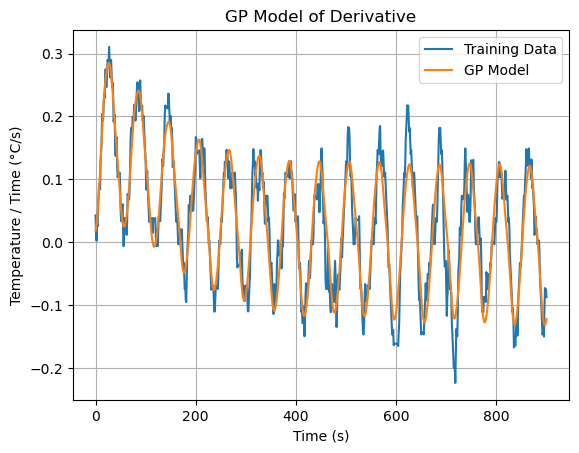

In [90]:
dTS1_GP = GP_dT.evaluate()

%matplotlib inline
plt.figure()
plt.plot(tvec, dTS1)
plt.plot(tvec, dTS1_GP)
plt.title("GP Model of Derivative")
plt.xlabel('Time (s)')
plt.ylabel('Temperature / Time (°C/s)')
plt.legend(['Training Data', 'GP Model'])
plt.grid()

## Application of Validated Dynamics $\dot{T} = f(T, Q, \dot{Q})$ to Step Test

### Setup

In [91]:
data_test = pd.read_csv(os.path.join(dir, "tclab_step_test.csv"))

tvec_test = data_test["Time"].values
TS1_test = data_test["T1"].values

### Smoothed Data

In [92]:
TS1_test_smooth = smooth(TS1_test, window)

dTS1_test = gradient_h4(TS1_test_smooth, tvec_test[1] - tvec_test[0])
dTS1f_test = interp1d(tvec_test, dTS1_test, kind='previous')  # piecewise, grab previous value

## In-Development FoKL-to-Pyomo Function

```python
from FoKL.fokl_to_pyomo import fix_betas
from FoKL.fokl_to_pyomo import fokl_to_pyomo
```

In [93]:
def fix_betas(mGP, betas):
    """Fix the already-initialized Pyomo beta variables to scalar values in 'betas', using last 'betas' draw as first Pyomo draw. Include average."""
    # Fix 'beta_avg':
    betas_avg = np.mean(betas[-len(mGP.draws)::, :], axis=0)
    for term in mGP.terms:
        mGP.beta_avg[term].fix(betas_avg[term])

        # Fix 'beta':
        for draw in mGP.draws:
            mGP.beta[draw, term].fix(betas[-(draw + 1), term])

In [94]:
def _gp_as_pyomo(name, tvec, phis, draws, mtx, betas):
    """tvec == m.t"""
    # Initialize sub-model for GP:
    mGP = pyo.ConcreteModel(name)

    # Some constants:
    mtx = np.array(mtx, dtype=int)  # indices/orders of basis functions (where 1 is B1 and 0 means none)

    # Some sets:
    mGP.draws = pyo.Set(initialize = range(draws))
    mGP.terms = pyo.Set(initialize = range(mtx.shape[0] + 1))  # terms (including beta0)
    mGP.orders = pyo.Set(initialize = np.unique(mtx[mtx != 0]))  # orders of basis functions
    mGP.attributes = pyo.Set(initialize = range(mtx.shape[1]))  # input variables

    # Define beta variables:
    mGP.beta = pyo.Var(mGP.draws, mGP.terms, domain=pyo.Reals)
    mGP.beta_avg = pyo.Var(mGP.terms, domain=pyo.Reals)
    fix_betas(mGP, betas)

    # Define normalized attributes (i.e., input variables):
    mGP.x = pyo.Var(tvec, mGP.attributes, initialize=0.0, domain=pyo.Reals, bounds=(0, 1))

    # ===================================================================
    # Define polynomials (i.e., "basis" functions):
    
    nj = []  # list of [order, attribute] combinations used in GP
    for attribute in mGP.attributes:
        orders_j = np.unique(mtx[:, attribute])
        if any(orders_j != 0):
            for order_j in orders_j[orders_j != 0]:
                nj.append([order_j, attribute])
    
    mGP.phi = pyo.Var(tvec, nj, initialize=0.0, domain=pyo.Reals)

    def _eq_phi(mGP, t, n, j):
        """FoKL's 'basis' functions."""
        nm1 = n - 1  # Python indexing, since n=1 refers to B1 which is phis[0]
        return mGP.phi[t, n, j] == phis[nm1][0] + sum(phis[nm1][k] * mGP.x[t, j] ** k for k in range(1, len(phis[nm1])))

    mGP.constr_phi = pyo.Constraint(tvec, nj, rule=_eq_phi)

    # ===================================================================
    # Build GP expression:

    # Draws:

    mGP.y = pyo.Var(tvec, mGP.draws, initialize=0.0, domain=pyo.Reals)

    def _eq_y(mGP, t, draw):
        """FoKL's GP equation."""
        y = mGP.beta[draw, 0]  # initialize
        
        for term in range(1, len(mGP.terms)):  # == m.terms[1::]
            y_term = mGP.beta[draw, term]

            for j in mGP.attributes:
                n = mtx[term - 1, j]

                if n != 0:  # since 0 means none
                    y_term *= mGP.phi[t, n, j]

            y += y_term

        return mGP.y[t, draw] == y

    mGP.constr_y = pyo.Constraint(tvec, mGP.draws, rule=_eq_y)

    # Average:

    mGP.y_avg = pyo.Var(tvec, initialize=0.0, domain=pyo.Reals)

    def _eq_y_avg(mGP, t):
        """FoKL's GP equation, averaged across draws."""
        y = mGP.beta_avg[0]  # initialize
        
        for term in range(1, len(mGP.terms)):  # == m.terms[1::]
            y_term = mGP.beta_avg[term]

            for j in mGP.attributes:
                n = mtx[term - 1, j]

                if n != 0:  # since 0 means none
                    y_term *= mGP.phi[t, n, j]

            y += y_term

        return mGP.y_avg[t] == y

    mGP.constr_y_avg = pyo.Constraint(tvec, rule=_eq_y_avg)

    # Standard deviation:

    mGP.y_std = pyo.Var(m.t, initialize=0.0, domain=pyo.Reals)

    def _eq_y_std(mGP, t):
        """Standard deviation of draws from FoKL's GP equation."""
        return mGP.y_std[t] == sqrt(sum(mGP.y[t, draw] ** 2 for draw in mGP.draws) / len(mGP.draws) + 1e-9)

    mGP.constr_y_std = pyo.Constraint(tvec, rule=_eq_y_std)

    return mGP

In [95]:
def fokl_to_pyomo(self, xvars, yvar, m=None, draws=None, t_span=None, mtx=None, betas=None, minmax=None):
    """
    
    Reserved components:
        - m.t

    Tips:
        - use 'None' to avoid automatic generation of 'xvars' and 'yvar' components
        
    """
    # Process arguments:

    if m is None:
        m = pyo.ConcreteModel('Global')

    if m.find_component('t') is None:
        if t_span is None:  # ODE not requested, so single index to avoid if-else statements in internal code
            m.t = pyo.Set(initialize=range(1))
        elif isinstance(t_span, list):
            m.t = dae.ContinuousSet(bounds=t_span)
        else:
            raise ValueError("Argument 't_span' must be a list of integration bounds.")
    elif t_span is not None:
        warnings.warn("Ignoring argument 't_span' because 'm.t' is already defined.", category=UserWarning)

    if not isinstance(xvars, list):  # if not list, make list
        xvars = [xvars]
    if isinstance(yvar, list):  # if list, make not list
        yvar = yvar[0]

    j = -1
    for xvar in xvars:
        j += 1
        if isinstance(xvar, str):  # else pre-defined Pyomo component, so ignore
            m.add_component(xvar, pyo.Var(m.t, initialize=0.0, domain=pyo.Reals))
            xvars[j] = m.component(xvar)

    if isinstance(yvar, str):  # else pre-defined Pyomo component, so ignore
        m.add_component(yvar, pyo.Var(m.t, initialize=0.0, domain=pyo.Reals))
        yvar = m.component(yvar)

    if draws is None:
        draws = self.draws

    if mtx is None:
        mtx = self.mtx

    if betas is None:
        betas = self.betas

    if minmax is None:
        minmax = self.minmax

    # ======================================
    # ======================================

    # Find next available GP index:
    i = 0
    while m.find_component(f"GP{i}") is not None:
        i += 1

    # Create Pyomo model with GP:
    mGP = _gp_as_pyomo(f"GP{i}", m.t, self.phis, draws, mtx, betas)

    # Apply normalization:
    
    def _eq_norm(mGP, t, j):
        """Normalization constraint."""
        if xvars[j] is not None:  # else ignore
            return mGP.x[t, j] == (xvars[j][t] - minmax[j][0]) / (minmax[j][1] - minmax[j][0])
        else:
            warnings.warn(f"Normalization constraint was not applied to GP attribute (index={j}) because 'xvars[{j}]=None'. Assuming user will define variable and its corresponding normalization constraint manually.", category=UserWarning)

    mGP.constr_norm = pyo.Constraint(m.t, mGP.attributes, rule=_eq_norm)

    # Set 'yvar' equal to GP:
    
    def _constr_yvar(mGP, t):
        """Set 'yvar' equal to GP."""
        if yvar is not None:  # else ignore
            return yvar[t] == mGP.y_avg[t]
        else:
            warnings.warn("Equivalence constraint was not applied to GP output because 'yvar=None'. Assuming user will define variable and its corresponding equivalence constraint manually.", category=UserWarning)
    
    mGP.constr_yvar = pyo.Constraint(m.t, rule=_constr_yvar)

    # Merge 'mGP' with global Pyomo model:
    m.add_component(f"GP{i}", mGP)

    return m

## Controller Reference Trajectory

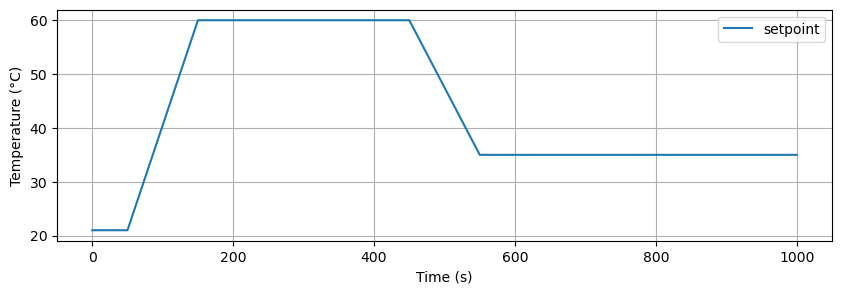

In [96]:
# time grid
t0 = 0
tf = 1000
dt = 2
n = round(tf / dt)
t_grid = np.linspace(t0, 1000, n + 1)

# ambient temperature
Tamb = 21

# setpoint/reference
def r(t):
    return np.interp(t, [0, 50, 150, 450, 550], [Tamb, Tamb, 60, 60, 35])

# plot the setpoint function
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(t_grid, r(t_grid), label="setpoint")
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel("Time (s)")
ax.legend()
ax.grid(True)

## Optimization using GP Model

Reference for optimization of benchmark model: https://dowlinglab.github.io/pyomo-doe/notebooks/pyomo_simulation.html#controlling-to-a-reference-tractory

In [97]:
# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater with GP Model')

# Define time domain
m.t = dae.ContinuousSet(bounds=(t0, tf))

# ======================================================
# ======================================================

# Define 'fokl_to_pyomo' arguments:

# Define the state variables as a function of time
m.Ts1 = pyo.Var(m.t)

# Define the control variable (heater power) as a function of time
m.u1 = pyo.Var(m.t, bounds=(0, 100))

# Define the derivative of the control variable
m.du1 = dae.DerivativeVar(m.u1)

xvars = [m.Ts1, m.u1, m.du1]
yvar = 'dTs1_GP'
draws = 5

In [98]:
fokl_to_pyomo(GP_dT, xvars, yvar, m, draws)

In [99]:
m.pprint()

3 Var Declarations
    Ts1 : Size=2, Index=t
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
           0 :  None :  None :  None : False :  True :  Reals
        1000 :  None :  None :  None : False :  True :  Reals
    dTs1_GP : Size=2, Index=t
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
           0 :  None :   0.0 :  None : False : False :  Reals
        1000 :  None :   0.0 :  None : False : False :  Reals
    u1 : Size=2, Index=t
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
           0 :     0 :  None :   100 : False :  True :  Reals
        1000 :     0 :  None :   100 : False :  True :  Reals

1 Block Declarations
    GP0 : Size=1, Index=None, Active=True
        4 Set Declarations
            attributes : Size=1, Index=None, Ordered=Insertion
                Key  : Dimen : Domain : Size : Members
                None :     1 :    Any :    3 : {0, 1, 2}
            draws : Size=1, Index=None, Ordered=Insertion
                Ke

In [100]:
# Define the derivatives of the state variables
m.dTs1 = dae.DerivativeVar(m.Ts1)

# Define the integral of the squared error
@m.Integral(m.t)
def ise(m, t):
    return (r(t) - m.Ts1[t]) ** 2

# Define the second differential equation
@m.Constraint(m.t)
def sensor1(m, t):
    return m.dTs1[t] == m.dTs1_GP[t]

# Fix the initial conditions
m.Ts1[t0].fix(Tamb)  # or is it integer indexing for ContinuousSet --> 'm.Ts1[0]' ???

# Define the objective function
@m.Objective(sense=pyo.minimize)
def objective(m):
    return m.ise

model.name="TCLab Heater with GP Model";
    - termination condition: other
    - message from solver: <undefined>


{'Solver': [{'Status': 'warning', 'Termination condition': 'other'}]}

In [ ]:
m.pprint()

In [ ]:
# Apply a collocation method to numerically integrate the differential equations
pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)

# Call our nonlinear optimization/equation solver, Ipopt
pyo.SolverFactory('ipopt').solve(m)